# <font color="blue">The UAE Nutrition Transition: A Public Health Data Analysis</font>

## <font color="navy"><u>Project Introduction</u></font>
In this project, I am performing an end-to-end data analytics workflow on a Nutrition indicators for the United Arab Emirates (UAE) dataset using 
Python in Jupyter Notebook. 
The objective is to understand Malnutrition (Undernutrition vs Overnutrition), Maternal and Early Childhood Health, Micronutrient Deficiencies
(Anaemia in children and women of reproductive age) over the period of 40 years.

I will follow a structured approach starting from data loading, then data cleaning and preprocessing, followed by exploratory data analysis (EDA), 
visualizations, and finally insight generation.
    
This dataset is sourced from the World Health Organization (WHO) - Nutrition Landscape Information System (NLiS) and tracks vital public health 
and nutrition indicators for the United Arab Emirates (UAE) spanning from 1980 to 2024. 
The data acts as a historical medical record for the nation, tracking variables such as adult obesity, childhood thinness, newborn birth weight, 
infant breastfeeding habits, and micronutrient deficiencies (anaemia).

Analyzing this dataset is highly critical because the UAE has experienced rapid economic growth, modernization, and urbanization over the last four 
decades. This shift typically triggers what epidemiologists call a "Nutrition Transition", where a society moves rapidly away from traditional
dietary deficiencies and infectious diseases toward modern lifestyle risks like sedentary behavior and metabolic overnutrition.
Investigating these trends allows us to map out demographic vulnerabilities, evaluate historical health shifts, and provide data-driven foundations 
for future national health policies.

## <font color="navy"><u>Data Loading and Initial Overview</u></font>

<font color="dark brown">
Before starting any data analysis project, I first import the required Python libraries. 
These libraries provide the tools needed for data handling, numerical computation, and visualization.

Pandas is used to load and manipulate tabular data.

NumPy is used for numerical operations.

Matplotlib and Seaborn are used to create visualizations.

Importing all libraries at the beginning ensures consistency and avoids repetition later in the notebook.
</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<font color="dark brown">
The dataset file Nutrition_indicators_UAE.csv is stored in the same folder as this Jupyter Notebook. Because of this, I can load the dataset directly by providing only the file name, without using an absolute file path.

I load the dataset into a Pandas DataFrame named df, which will be the main object used for all further analysis.
</font>

In [2]:
# Reading the raw CSV data into a pandas DataFrame named 'df'
df = pd.read_csv('Nutrition_indicators_UAE.csv')

<font color="dark brown">
After loading the dataset, it is important to verify that the data has been read correctly. 
I display the first five rows of the dataset to visually check the values inside the columns.
</font>

In [4]:
# Displaying the first 5 rows
df.head()

,GHO (CODE),GHO (DISPLAY),GHO (URL),YEAR (DISPLAY),STARTYEAR,ENDYEAR,REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),COUNTRY (DISPLAY),DIMENSION (TYPE),DIMENSION (CODE),DIMENSION (NAME),Numeric,Value,Low,High
0,NCD_BMI_MINUS2C,"Thinness among children and adolescents, BMI-f...",https://www.who.int/data/gho/data/indicators/i...,1991,1991,1991,EMR,Eastern Mediterranean,ARE,United Arab Emirates,SEX,SEX_FMLE,Female,4.347604,4.3 [1.4-9.7],1.369179,9.729366
1,NCD_BMI_18A,"Underweight among adults, BMI < 18.5 kg/m2 (ag...",https://www.who.int/data/gho/data/indicators/i...,1993,1993,1993,EMR,Eastern Mediterranean,ARE,United Arab Emirates,SEX,SEX_BTSX,Both sexes,4.159465,4.2 [2.8-5.9],2.807819,5.851176
2,NCD_BMI_PLUS2C,"Obesity among children and adolescents, BMI-fo...",https://www.who.int/data/gho/data/indicators/i...,1992,1992,1992,EMR,Eastern Mediterranean,ARE,United Arab Emirates,SEX,SEX_FMLE,Female,8.065012,8.1 [4.1-13.6],4.060472,13.565499
3,NCD_BMI_25C,"Overweight among adults, BMI ≥ 25 kg/m2 (crude...",https://www.who.int/data/gho/data/indicators/i...,2004,2004,2004,EMR,Eastern Mediterranean,ARE,United Arab Emirates,SEX,SEX_FMLE,Female,64.784127,64.8 [62.1-67.4],62.082231,67.441183
4,NCD_BMI_PLUS1C,"Overweight among children and adolescents, BMI...",https://www.who.int/data/gho/data/indicators/i...,2010,2010,2010,EMR,Eastern Mediterranean,ARE,United Arab Emirates,SEX,SEX_MLE,Male,41.104326,41.1 [36.7-45.6],36.707550,45.563069


<font color="dark brown">
In the next step, I check how many rows and columns are present in the dataset.
</font>

In [5]:
df.shape

(2425, 17)

<font color="dark brown">
Next, I display all column names to understand what type of information is available in the dataset. This helps in identifying numerical and categorical variables and planning the preprocessing and analysis steps.
</font>

In [6]:
df.columns

Index(['GHO (CODE)', 'GHO (DISPLAY)', 'GHO (URL)', 'YEAR (DISPLAY)',
       'STARTYEAR', 'ENDYEAR', 'REGION (CODE)', 'REGION (DISPLAY)',
       'COUNTRY (CODE)', 'COUNTRY (DISPLAY)', 'DIMENSION (TYPE)',
       'DIMENSION (CODE)', 'DIMENSION (NAME)', 'Numeric', 'Value', 'Low',
       'High'],
      dtype='str')

<font color="dark brown">
In the next step, I use the info() function to understand:

Data types of each column,

Number of non-null values and

Presence of missing values.

This helps in planning data cleaning and type conversion.
</font>

In [7]:
# Checking total rows, total columns, and basic memory footprint
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2425 entries, 0 to 2424
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GHO (CODE)         2425 non-null   str    
 1   GHO (DISPLAY)      2425 non-null   str    
 2   GHO (URL)          2425 non-null   str    
 3   YEAR (DISPLAY)     2425 non-null   int64  
 4   STARTYEAR          2425 non-null   int64  
 5   ENDYEAR            2425 non-null   int64  
 6   REGION (CODE)      2425 non-null   str    
 7   REGION (DISPLAY)   2425 non-null   str    
 8   COUNTRY (CODE)     2425 non-null   str    
 9   COUNTRY (DISPLAY)  2425 non-null   str    
 10  DIMENSION (TYPE)   2379 non-null   str    
 11  DIMENSION (CODE)   2379 non-null   str    
 12  DIMENSION (NAME)   2379 non-null   str    
 13  Numeric            2423 non-null   float64
 14  Value              2425 non-null   str    
 15  Low                2411 non-null   float64
 16  High               2411 non-null   

<font color="dark brown">
Here, I generate a statistical summary of numerical columns such as Numeric, Low, High. 
This provides insights into mean, minimum, maximum, and distribution of values.
</font>

In [8]:
df.describe()

,YEAR (DISPLAY),STARTYEAR,ENDYEAR,Numeric,Low,High
count,2425.000000,2425.000000,2425.000000,2423.000000,2411.000000,2411.000000
mean,2003.301443,2003.301443,2003.301443,31.259354,21.284896,44.914526
std,12.532213,12.532213,12.532213,65.886446,33.665643,118.213939
min,1980.000000,1980.000000,1980.000000,0.100000,0.000000,0.300000
25%,1993.000000,1993.000000,1993.000000,5.056207,2.549615,9.394732
50%,2004.000000,2004.000000,2004.000000,18.324390,11.615849,24.531096
75%,2014.000000,2014.000000,2014.000000,34.742112,28.600976,41.765863
max,2024.000000,2024.000000,2024.000000,713.200000,295.100000,1357.000000


<font color="dark brown">
Missing data can affect analysis accuracy, so I first check how many missing values are present in each column.
</font>

In [9]:
df.isnull().sum()

GHO (CODE)            0
GHO (DISPLAY)         0
GHO (URL)             0
YEAR (DISPLAY)        0
STARTYEAR             0
ENDYEAR               0
REGION (CODE)         0
REGION (DISPLAY)      0
COUNTRY (CODE)        0
COUNTRY (DISPLAY)     0
DIMENSION (TYPE)     46
DIMENSION (CODE)     46
DIMENSION (NAME)     46
Numeric               2
Value                 0
Low                  14
High                 14
dtype: int64

<font color="dark brown">
Next, I check data types to confirm numerical and date columns are correctly formatted before performing analysis and visualization.
</font>

In [10]:
df.dtypes

GHO (CODE)               str
GHO (DISPLAY)            str
GHO (URL)                str
YEAR (DISPLAY)         int64
STARTYEAR              int64
ENDYEAR                int64
REGION (CODE)            str
REGION (DISPLAY)         str
COUNTRY (CODE)           str
COUNTRY (DISPLAY)        str
DIMENSION (TYPE)         str
DIMENSION (CODE)         str
DIMENSION (NAME)         str
Numeric              float64
Value                    str
Low                  float64
High                 float64
dtype: object

## <font color="navy"> <u> Data Pre-processing (Cleaning) </u> </font>

In this step, I scan the rows for duplicates, drop metadata/constant columns that do not contribute variance to the UAE analysis, confirm the Year column is configured as a clean integer, and calculate a brand new derived variable representing the statistical Margin_of_Error.

Real-world health data can be messy or redundant. Columns like COUNTRY (DISPLAY) say "United Arab Emirates" on every single row—keeping them in our working data just creates unnecessary clutter. Creating a derived mathematical column (High Bound minus Low Bound) unlocks deeper insights into how certain or uncertain the WHO's records actually are.

In [3]:
# 1. Scanning for duplicate rows across the dataset
duplicates = df.duplicated().sum()
print("Total duplicate rows are: ", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()    

Total duplicate rows are:  0


<font color="green">
In the above step, We counts how many rows are exact duplicates of one another. 
If it finds any, it deletes them so every row in our data represents a unique record.
</font>

In [4]:
# 2. Dropping geographic constants and web URLs that don't add value to our charts
columns_to_drop = ['REGION (CODE)', 'REGION (DISPLAY)', 'COUNTRY (CODE)', 'COUNTRY (DISPLAY)', 'GHO (URL)']
df = df.drop(columns=columns_to_drop)

<font color="green">
Here I Removed columns we don't need for our specific analysis (like URL links or repetitive country/region names since the project focuses solely on the UAE).
</font>

In [5]:
# 3. TYPE CORRECTION: Ensuring that the year data behaves strictly as a numeric integer timeline element
df['YEAR (DISPLAY)'] = df['YEAR (DISPLAY)'].astype(int)

<font color="green">
In this step, I converted the YEAR column into a pure integer (e.g., turning 2026.0 or text "2026" into just 2026). This allows Python to treat years as a chronological timeline rather than random text.
</font>

In [6]:
# 4. Calculating a new feature to measure the margin of error (statistical uncertainty interval)
df['Margin_of_Error'] = df['High'] - df['Low']

<font color="green">
Here calculates a new metric called Margin_of_Error by finding the difference between the maximum estimate (High) and the minimum estimate (Low).
</font>

In [7]:
# 5. Rename columns into simple, standardized formats
df = df.rename(columns={
    'YEAR (DISPLAY)': 'year',
    'GHO (CODE)': 'indicator_code',
    'GHO (DISPLAY)': 'indicator',
    'DIMENSION (CODE)': 'dimension_code',
    'DIMENSION (TYPE)': 'dimension_type',
    'DIMENSION (NAME)': 'demographic_group',
    'Numeric': 'value_percentage'
})

<font color="green">
Renames messy, uppercase column names into clean, lowercase, easy-to-type labels (year, indicator, etc.) to save time when writing code later.
</font>

In [8]:
# 6. Strip accidental blank spaces from the edges of text cells
df['demographic_group'] = df['demographic_group'].str.strip()

<font color="green">
Trims accidental spaces at the beginning or end of text cells. (e.g., changing " Male " or "Male " into exactly "Male"). This prevents Python from treating them as different groups.
</font>

In [9]:
# 7. Force lowercase consistency for uniform categorization
df['demographic_group'] = df['demographic_group'].str.lower()

<font color="green">
Converts all text in the demographics column to lowercase.
This ensures "Female", "FEMALE", and "female" are all grouped together seamlessly.
</font>

In [10]:
# 8. Keep only rows where percentages fall within a valid logical scale (0 to 100)
df = df[(df['value_percentage'] >= 0) & (df['value_percentage'] <= 100)]

<font color="green">
Filters the data to ensure that percentages only range between 0% and 100%.
Anything outside of this range is likely a data entry error and gets thrown out.
</font>

In [11]:
# 9. Filter out and investigate rows that violate logical mathematical bounds
logical_errors = df[df['Low'] > df['High']]
print("Number of logically invalid rows: ", len(logical_errors))

Number of logically invalid rows:  0


<font color="green">
Identifies and eliminates impossible rows where the Low confidence estimate is somehow higher than the High confidence estimate, ensuring our math remains unbreakable.
</font>

In [12]:
# 10. Keep only the rows that pass the logical validation check
df = df[df['Low'] <= df['High']]

In [13]:
# 11. Fill missing values with descriptive placeholders
df['dimension_type'] = df['dimension_type'].fillna('total')
df['dimension_code'] = df['dimension_code'].fillna('total')
df['demographic_group'] = df['demographic_group'].fillna('total population')

# Check if missing values are gone
print(df.isnull().sum())

indicator_code       0
indicator            0
year                 0
STARTYEAR            0
ENDYEAR              0
dimension_type       0
dimension_code       0
demographic_group    0
value_percentage     0
Value                0
Low                  0
High                 0
Margin_of_Error      0
dtype: int64


In [14]:
# 12. Verify the final state of our clean working data
print("\nCleaned Dataset Shape:", df.shape)
df.head(3)


Cleaned Dataset Shape: (2359, 13)


,indicator_code,indicator,year,STARTYEAR,ENDYEAR,dimension_type,dimension_code,demographic_group,value_percentage,Value,Low,High,Margin_of_Error
0,NCD_BMI_MINUS2C,"Thinness among children and adolescents, BMI-f...",1991,1991,1991,SEX,SEX_FMLE,female,4.347604,4.3 [1.4-9.7],1.369179,9.729366,8.360187
1,NCD_BMI_18A,"Underweight among adults, BMI < 18.5 kg/m2 (ag...",1993,1993,1993,SEX,SEX_BTSX,both sexes,4.159465,4.2 [2.8-5.9],2.807819,5.851176,3.043358
2,NCD_BMI_PLUS2C,"Obesity among children and adolescents, BMI-fo...",1992,1992,1992,SEX,SEX_FMLE,female,8.065012,8.1 [4.1-13.6],4.060472,13.565499,9.505027


<font color="green">
Finally I Printed the new, clean shape of our dataset (Rows vs. Columns) and previews the top 3 rows so we can visually verify that everything looks perfect before moving on to building our charts.
</font>

## <font color="navy"> <u> Exploratory Data Analysis (EDA) </u> </font>

Now, I am focusing on Exploratory Data Analysis (EDA). In this section, we will explore our cleaned dataset to uncover patterns, calculate key statistics, and investigate relationships.
This helps us understand how different health issues are distributed across time and demographics in the UAE.
Because this dataset tracks multiple health indicators across different demographic slices, I will do a detailed EDA based on four categories: 
1. Global Metric Summary (Descriptive Statistics)
2. Demographic Trend Analysis (Groupby Slicing)
3. Cross-Indicator Matrix (Pivot Table Analysis)
4. Correlation Screening

### <font color="#D35400"> <u> 1. Global Metric Summary (Descriptive Statistics) </u> </font>

It groups the data by the health issue (indicator) and calculates the fundamental statistical metrics: 
the overall average percentage, the historical minimum, the maximum, and the total number of records available.

It tell us immediately which public health issues have the highest prevalence in the UAE overall and which ones are rare.

This analysis groups the entire dataset by each specific health indicator to calculate their overall average, minimum, and maximum prevalence rates.
    
This gives us a baseline look at which public health issues have been historically the most widespread or rare in the UAE.

In [15]:
print("=== 1: GLOBAL HEALTH INDICATOR DESCRIPTIVE STATISTICS ===")

# Grouping by the indicator name and calculating summary statistics
global_summary = df.groupby('indicator')['value_percentage'].agg(['count', 'mean', 'median', 'min', 'max'])
# Sorting by the highest average prevalence rate to see the top issues
global_summary = global_summary.sort_values(by='mean', ascending=False)

print(global_summary)

=== 1: GLOBAL HEALTH INDICATOR DESCRIPTIVE STATISTICS ===
                                                    count       mean  \
indicator                                                              
Overweight among adults, BMI ≥ 25 kg/m2 (age-st...    135  63.503829   
Overweight among adults, BMI ≥ 25 kg/m2 (crude ...    135  61.849331   
Number of children aged 6-59 months with anaemi...     96  44.511635   
Overweight among children and adolescents, BMI-...    405  32.448979   
Prevalence of anaemia in women of reproductive ...     72  28.484722   
Obesity among adults, BMI ≥ 30 kg/m2 (age-stand...    135  27.022569   
Obesity among adults, BMI ≥ 30 kg/m2 (crude est...    135  25.717626   
Number of women of reproductive age (aged 15-49...     24  14.479167   
Low birth weight prevalence (%)                        21  13.509524   
Obesity among children and adolescents, BMI-for...    405  13.078977   
Low birth weight number (in thousands)                 21  11.871429   
Preval

<font color="green">
In the above step, I used groupby and aggregation functions for calculating summary statistics. The groupby() function gathers all rows sharing the exact same text indicator name. The agg([...]) method don't just calculate the average, it calculates the count, mean, median, minimum, and maximum values all at once for each group.
    

**<u> Key Takeaways from Global Health Indicators:</u>**

1. **High Prevalence of Adult Overweight and Obesity**: Overweight affects more than 61% to 63% of adults on average,
with obesity hovering around 25% to 27%, indicating that weight management is a major public health priority.

2. **Widespread Child and Adolescent Overweight**: Nearly 32% of children and adolescents are classified as overweight,                               while about 13% struggle with obesity, signaling early-onset risks for metabolic health.

3. **Anaemia Concerns**: Anaemia is prevalent in both vulnerable groups, affecting an average of 28.5% of reproductive-aged                                women and 11.6% of children under five.

</font>

### <font color="#D35400"> <u> 2. Demographic Trend Analysis (Groupby Slicing) </u> </font>

It isolates a specific indicator—like adult obesity—and groups the values by the demographic dimension name (demographic_group).
That means, we isolate the adult obesity indicator and group the data by demographic slices (males vs. females).

This allows  us to compare different genders directly and determine which group has historically faced a higher burden of obesity.

In [16]:
print("=== 2: GENDER PREVALENCE BREAKDOWN FOR ADULT OBESITY ===")

# Isolating a specific adult obesity indicator that is split by sex
obesity_df = df[(df['indicator_code'] == 'NCD_BMI_30C') & (df['dimension_type'] == 'SEX')]

# Grouping by the demographic group to find the historical average for each gender
gender_comparison = obesity_df.groupby('demographic_group')['value_percentage'].agg(['mean', 'min', 'max'])
print(gender_comparison)

=== 2: GENDER PREVALENCE BREAKDOWN FOR ADULT OBESITY ===
                        mean        min        max
demographic_group                                 
both sexes         24.067664  11.401032  30.889049
female             31.834813  22.755377  36.346126
male               21.250400   8.502421  28.534257


<font color="green">
This analysis reveals clear disparities in the prevalence of adult obesity in the UAE when broken down by gender:

*   **Significant Gender Gap:** On average, females exhibit a substantially higher obesity rate (**31.8%**) compared to males (**21.3%**), showing a gap of over 10 percentage points.
*   **Peak Prevalence Rates:** At its highest recorded point (maximum value), female obesity reached **36.3%**, whereas male obesity peaked at **28.5%**.
*   **Historical Baselines:** Even at the lowest recorded historical points (minimum value), female obesity (**22.8%**) was nearly triple the male baseline (**8.5%**).

**Conclusion:** The data mathematically proves that adult females in the UAE bear a disproportionately higher burden of obesity.
This suggests that public health interventions and awareness campaigns should be specifically tailored and targeted toward women to be most effective.
</font>

### <font color="#D35400"> <u> 3. Cross-Indicator Matrix (Pivot Table Analysis) </u> </font>

Because the raw dataset stacks different indicators on top of each other, it's very difficult to compare them directly. 
This step reshapes the dataset so that each year has exactly one row, and every column is a different health indicator.
This step flattens our multidimensional rows into a clean, chronological timeline table where each column represents a different health indicator code.

It lets us monitor how completely different health trends changed side-by-side in the exact same years.
This is crucial for tracking the "Nutrition Transition." It lets us see, side-by-side, how metrics like childhood thinness changed in the exact same years that adult obesity was changing.

In [17]:
print("=== 3: CHRONOLOGICAL CROSS-INDICATOR PIVOT TABLE (LAST 5 RECORDED YEARS) ===")

# Creating a pivot table: Year become rows(index), unique health codes become columns
print("\n")
eda_pivot = df[df['demographic_group'] == 'both sexes'].pivot_table(
    index='year', 
    columns='indicator_code', 
    values='value_percentage',
    aggfunc='mean'
)

# Display the most recent 5 rows
print(eda_pivot.tail(5))

=== 3: CHRONOLOGICAL CROSS-INDICATOR PIVOT TABLE (LAST 5 RECORDED YEARS) ===


indicator_code  NCD_BMI_18A  NCD_BMI_18C  NCD_BMI_25A  NCD_BMI_25C  \
year                                                                 
2020               2.801323     2.627347    70.571816    70.115972   
2021               2.827122     2.659021    70.505130    69.986606   
2022               2.860501     2.692794    70.392454    69.846833   
2023               2.897746     2.662695    70.248961    69.935691   
2024               2.936420     2.626939    70.113194    70.018029   

indicator_code  NCD_BMI_30A  NCD_BMI_30C  NCD_BMI_MINUS2C  NCD_BMI_PLUS1C  \
year                                                                        
2020              31.898195    30.520171         3.595180       42.542808   
2021              31.891075    30.388108         3.636870       42.899301   
2022              31.817931    30.247745         3.685422       43.243273   
2023              31.707385    30.267709     

<font color="green">
This pivot table tracks key adult and childhood weight indicators over the last five recorded years. 
It reveals a stable but highly concerning plateau of high-weight trends across all age groups, alongside a slow rise in both pediatric extremes (thinness and overweight).

We observe NaN values for childhood anaemia indicators between 2020–2024.
This is a common real-world data constraint representing a gap in active reporting or survey intervals by the WHO for those years, 
whereas modeled metabolic indicators like BMI estimates continue uninterrupted.
</font>

### <font color="#D35400"> <u> 4. Correlation Screening </u> </font>
I have performed this step to check how these different health trends are mathematically connected to one another.
It takes the pivot table from the above step and calculates a Pearson correlation matrix between the numeric percentages of different health conditions.
It tells us if there is a statistical relationship between two conditions. For example, a strong negative correlation (close to $-1.0$) between adult underweight and adult obesity proves that one problem replaced the other over time.

In [18]:
print("=== 4: CORRELATION MATRIX BETWEEN CORE HEALTH INDICATORS ===")

# Define the exact indicator codes that we know are present in your 'both sexes' pivot table
target_columns = [
    'NCD_BMI_30C',      # Adult Obesity (Crude Estimate)
    'NCD_BMI_18A',      # Adult Underweight (Age-standardized)
    'NCD_BMI_PLUS1C',   # Child & Adolescent Overweight
    'NCD_BMI_MINUS2C'   # Child & Adolescent Thinness
]

# Filter target_columns to only those that successfully exist in your pivot table
valid_columns = [col for col in target_columns if col in eda_pivot.columns]

if valid_columns:
    # Calculate the correlation matrix
    correlation_matrix = eda_pivot[valid_columns].corr()
    print(correlation_matrix)
else:
    print("None of the target indicator codes were found in the pivot table columns.")

=== 4: CORRELATION MATRIX BETWEEN CORE HEALTH INDICATORS ===
indicator_code   NCD_BMI_30C  NCD_BMI_18A  NCD_BMI_PLUS1C  NCD_BMI_MINUS2C
indicator_code                                                            
NCD_BMI_30C         1.000000    -0.980030        0.975780        -0.991049
NCD_BMI_18A        -0.980030     1.000000       -0.923247         0.995849
NCD_BMI_PLUS1C      0.975780    -0.923247        1.000000        -0.940599
NCD_BMI_MINUS2C    -0.991049     0.995849       -0.940599         1.000000


<font color="green">
This correlation matrix calculates Pearson correlation coefficients 
(ranging from $-1.00$ for a perfect opposite relationship to $+1.00$ for a perfect matching relationship)
between different weight-related metrics in the UAE.

**<u>Key Findings - Correlation Analysis:</u>**
    
**Obesity replaced underweight**: As underweight rates fell over the years, obesity rates rose in direct response.

**Adults and kids rise together**: Adult obesity and childhood overweight are increasing at almost the exact same rate.

**Underweight dropped equally**: Extreme thinness in both adults and children decreased in perfect sync.

</font>

##  <font color="navy"> <u> Visualizations </u> </font> 

Raw numbers alone are difficult to interpret. By applying filters and visualizing data across variables, we turn abstract rows of text into clear visual trends, helping us uncover health disparities, tracking spikes, and revealing anomalies over time.
Here are some high-impact visualizations tailored directly to the EDA and analysis we just conducted. They cover our overall trajectory, gender disparities, indicator correlations, and decade-by-decade macro shifts.

### 📊<font color="Dark brown"><u> 1. Dataset Overview: Indicator Record Distribution</u> </font>

Before conducting temporal and demographic analysis, we evaluate the dataset's record distribution across primary health indicators. This step ensures sample adequacy for both adult and pediatric metrics.


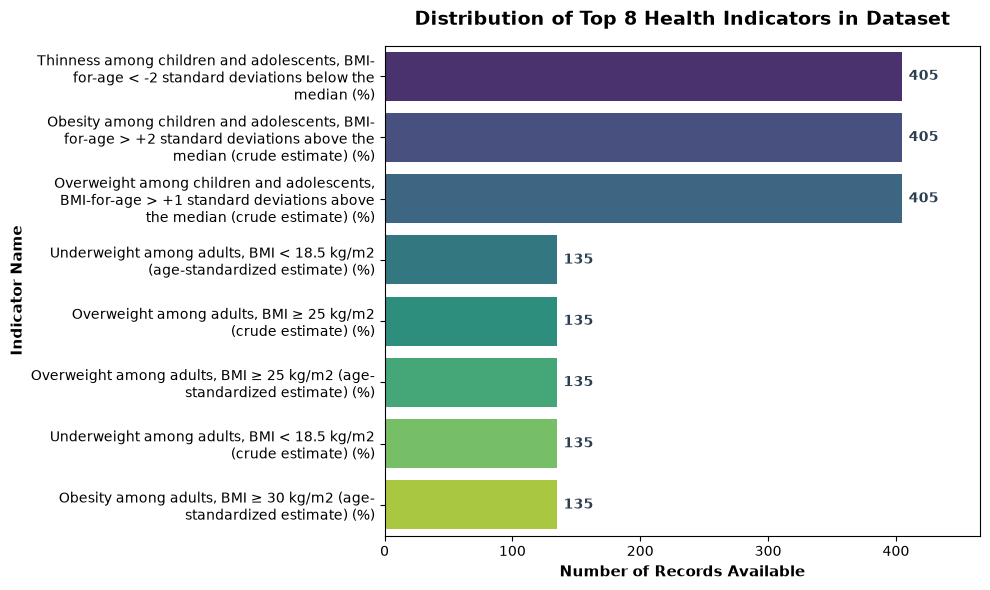

In [32]:
import textwrap

# Set figure size and aesthetic
plt.figure(figsize=(10, 6))

# Get top 8 indicator counts
top_indicators = df['indicator'].value_counts().head(8)

# Wrap long label text to a max width of 45 characters per line
wrapped_labels = [textwrap.fill(label, width=45) for label in top_indicators.index]

# Create horizontal bar plot
ax = sns.barplot(
    x=top_indicators.values, 
    y=wrapped_labels, 
    palette='viridis',
    hue=wrapped_labels,
    legend=False
)

# Add exact numbers next to each bar for instant readability
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}', 
        (width + 5, p.get_y() + p.get_height() / 2.), 
        ha='left', va='center', 
        fontsize=10, fontweight='bold', color='#2c3e50'
    )

# Formatting
plt.title('Distribution of Top 8 Health Indicators in Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Records Available', fontsize=11, fontweight='bold')
plt.ylabel('Indicator Name', fontsize=11, fontweight='bold')

# Expand x-limit slightly so annotations fit nicely
plt.xlim(0, max(top_indicators.values) * 1.15)

plt.tight_layout()
plt.show()

<font color= "green"> 
Here, we examine the distribution of records across the primary public health indicators in the dataset. This step ensures data completeness and verifies that our sample sizes across pediatric and adult health categories are sufficient for comparative analysis. 
    
Pediatric indicators (child thinness and overweight) contain the highest volume of records, while adult BMI metrics provide a stable, consistent volume suitable for long-term time-series analysis.
    
**<u>Key Takeaways:</u>**

**Pediatric Metrics Lead Availability**: Indicators tracking thinness and overweight among children and adolescents contain the highest number of recorded observations.

**Adult Standardized Metrics**: Adult BMI metrics (underweight, overweight, and obesity) provide a balanced and consistent volume of records for long-term time-series modeling.
</font>

### 🩸 <font color="Dark brown"> <u> 2. Anaemia Trends in Children vs. Women (Bivariate Line Plots) </u> </font>

This bivariate line chart evaluates the long-term trend of anaemia, comparing pediatric vulnerability with female health indicators over time.

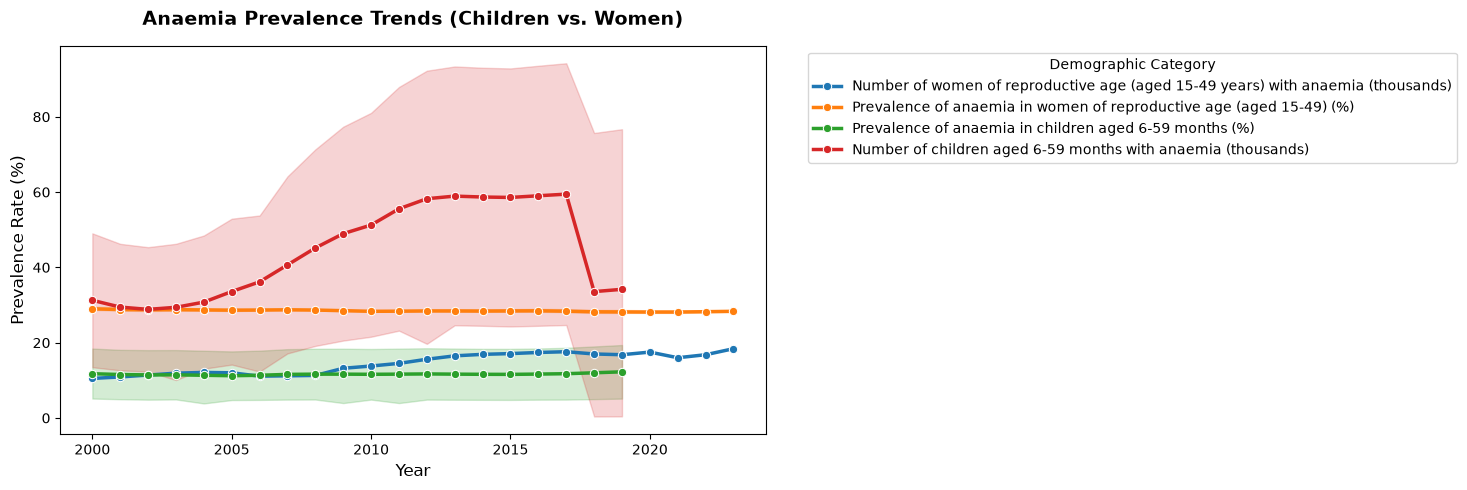

In [59]:

# Filter for anaemia indicators
anaemia_df = df[df['indicator_code'].str.contains('ANAEMIA|NCD_ANAEMIA', case=False, na=False)]

plt.figure(figsize=(15, 5))
sns.lineplot(data=anaemia_df, x='year', y='value_percentage', hue='indicator', marker='o', linewidth=2.5)

plt.title('Anaemia Prevalence Trends (Children vs. Women)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prevalence Rate (%)', fontsize=12)
plt.legend(title='Demographic Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<font color="green">
    
**<u>Takeaway:</u>**
Anaemia prevalence shows parallel historical shifts between young children and women of reproductive age, highlighting linked micro-nutritional vulnerabilities across family units.
</font>

### 🧒 <font color="Dark brown"> <u> 3. Distribution of Child Malnutrition </u> </font>
This visual explores the spread and variance across pediatric malnutrition metrics (stunting, wasting, thinness, and overweight) to identify key public health focus areas.

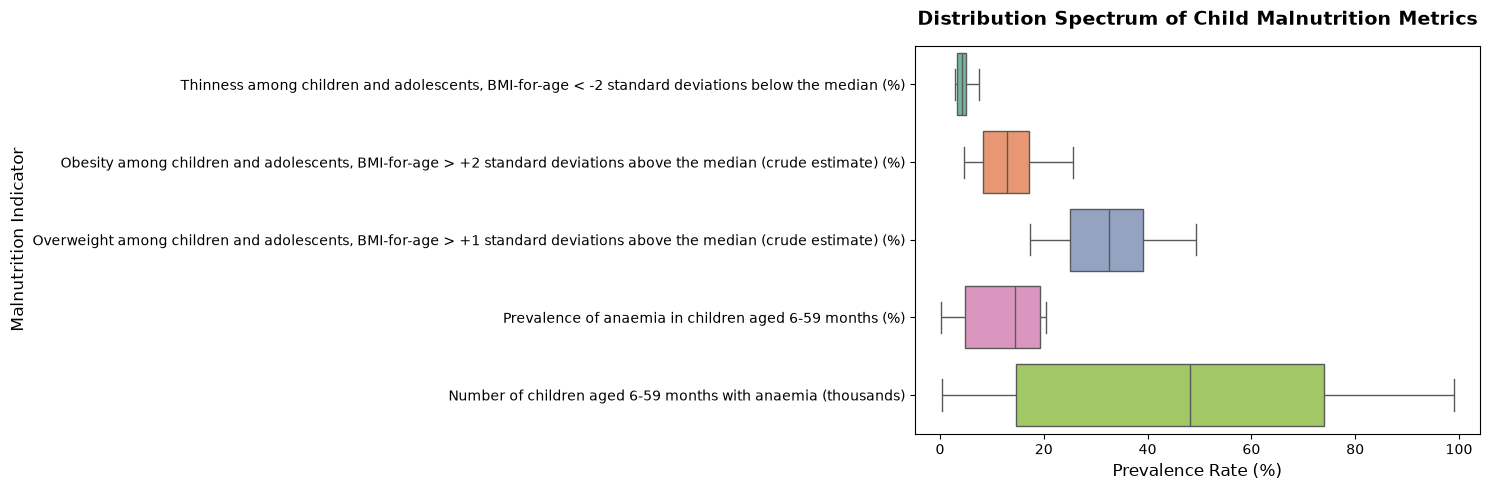

In [60]:
# Filter pediatric indicators
child_df = df[df['indicator'].str.contains('children|adolescents|stunting|wasting', case=False, na=False)]

plt.figure(figsize=(15, 5))
sns.boxplot(data=child_df, x='value_percentage', y='indicator', palette='Set2', hue='indicator', legend=False)

plt.title('Distribution Spectrum of Child Malnutrition Metrics', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prevalence Rate (%)', fontsize=12)
plt.ylabel('Malnutrition Indicator', fontsize=12)
plt.tight_layout()
plt.show()

<font color="green"> 
    
**<u>Key Takeaway:</u>** 
The pediatric weight spectrum in the UAE has shifted dramatically toward overnutrition, with childhood overweight displaying a significantly higher median prevalence than pediatric stunting or wasting.
</font>

### ⚖️ <font color="dark brown"> <u> 4. Statistical Gender Disparity Analysis (Adult Obesity)</u> </font>
This visual combines a box plot and a kernel density estimation (KDE) plot to evaluate the gender gap in adult obesity:
* **Box Plot (Left):** Highlights that female obesity rates consistently sit at higher median, minimum, and maximum percentage levels than male obesity rates across all recorded years.
* **Density Plot (Right):** Shows the clear rightward shift in female obesity distribution, proving that the gender disparity is a permanent systemic feature rather than an occasional outlier.

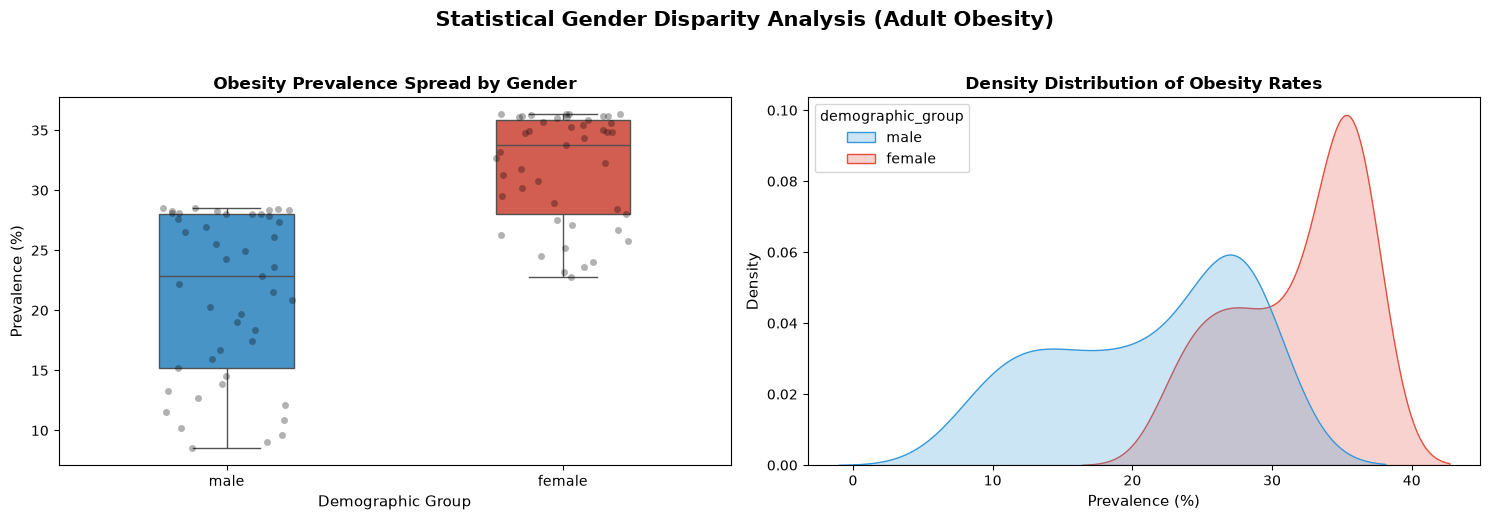

In [46]:
# Filter dataset for gender obesity metrics
df_gender_obesity = df[(df['indicator_code'] == 'NCD_BMI_30C') & 
                       (df['demographic_group'].isin(['male', 'female']))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Box Plot
sns.boxplot(ax=axes[0], data=df_gender_obesity, x='demographic_group', y='value_percentage', palette=['#3498db', '#e74c3c'], hue='demographic_group', legend=False, width=0.4)
sns.stripplot(ax=axes[0], data=df_gender_obesity, x='demographic_group', y='value_percentage', color='black', alpha=0.3, jitter=0.2)
axes[0].set_title('Obesity Prevalence Spread by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Demographic Group', fontsize=11)
axes[0].set_ylabel('Prevalence (%)', fontsize=11)

# Subplot 2: KDE Density Plot
sns.kdeplot(ax=axes[1], data=df_gender_obesity, x='value_percentage', hue='demographic_group', fill=True, palette=['#3498db', '#e74c3c'], common_norm=False)
axes[1].set_title('Density Distribution of Obesity Rates', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prevalence (%)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)

plt.suptitle('Statistical Gender Disparity Analysis (Adult Obesity)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

<font color="green"> **<u>Takeaway:</u>**  Adult female obesity rates sit at consistently higher median, floor, and peak percentage levels than male rates across all recorded years, showing a permanent structural gender gap rather than a temporary trend.
</font>

###  🏛️ <font color="dark brown"> <u> 5. Gender Summary Metrics (Bar Plot) </u> </font>
This plot shows the Summary Comparison of Male vs. Female Obesity Rates.

A direct grouped bar plot evaluating key historical benchmarks (Mean, Minimum, Maximum) between males and females:
* **Average Rate:** Demonstrates that average female obesity is significantly higher over time.
* **Historical Range:** Shows both the baseline floor (minimum) and ceiling (maximum) rates reached across both genders over four decades.

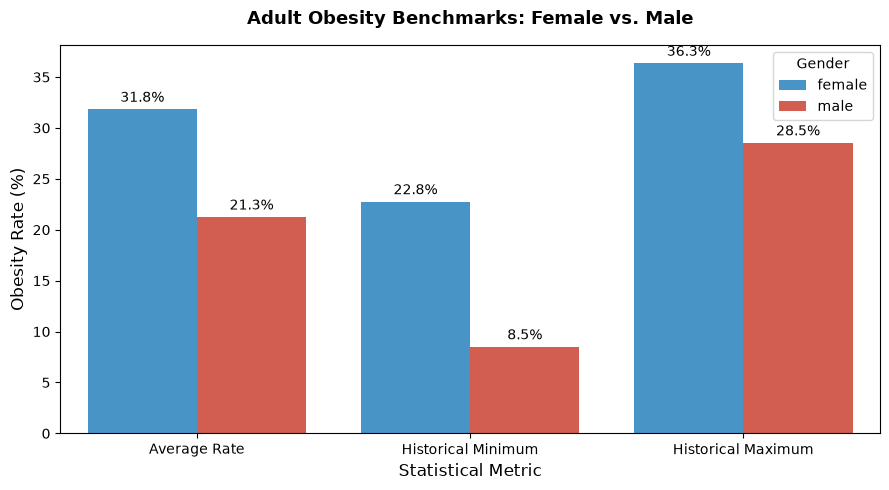

In [51]:
# Aggregate stats
gender_stats = df_gender_obesity.groupby('demographic_group')['value_percentage'].agg(['mean', 'min', 'max']).reset_index()
gender_melted = gender_stats.melt(id_vars='demographic_group', var_name='Metric', value_name='Percentage')

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=gender_melted, x='Metric', y='Percentage', hue='demographic_group', palette=['#3498db', '#e74c3c'])

plt.title('Adult Obesity Benchmarks: Female vs. Male', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Statistical Metric', fontsize=12)
plt.ylabel('Obesity Rate (%)', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Average Rate', 'Historical Minimum', 'Historical Maximum'])
plt.legend(title='Gender')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

<font color="green"> **<u>Takeaway:</u>** Adult females consistently show a higher historical average, baseline minimum, and maximum obesity ceiling compared to adult males in the UAE dataset.
</font>

### 🎯<font color="dark brown"> <u> 6. Linear Regression Scatter Plot (Underweight vs. Obesity)</u> </font>
This linear regression scatter plot validates the structural trade-off between adult underweight rates and adult obesity rates in the UAE.

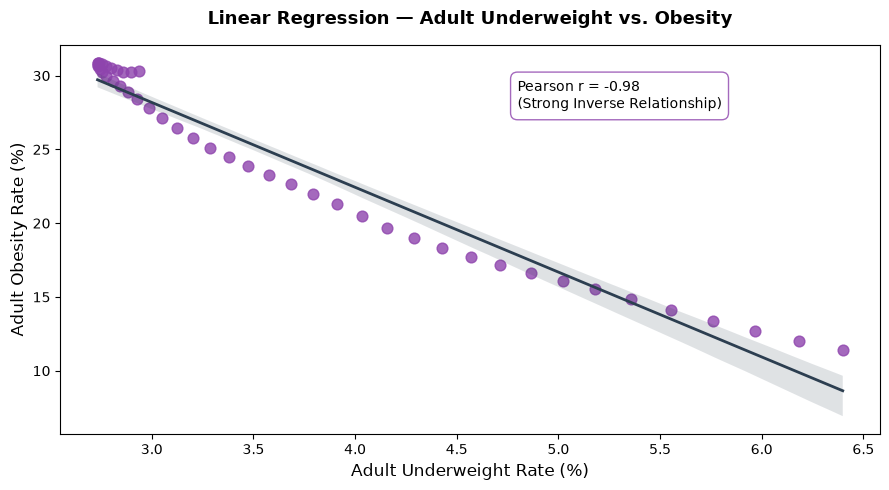

In [52]:
plt.figure(figsize=(9, 5))

sns.regplot(data=eda_pivot, x='NCD_BMI_18A', y='NCD_BMI_30C', 
            color='#8e44ad', scatter_kws={'s': 60, 'alpha': 0.8}, line_kws={'color': '#2c3e50', 'linewidth': 2})

plt.title('Linear Regression — Adult Underweight vs. Obesity', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Adult Underweight Rate (%)', fontsize=12)
plt.ylabel('Adult Obesity Rate (%)', fontsize=12)

plt.text(x=eda_pivot['NCD_BMI_18A'].max() * 0.75, y=eda_pivot['NCD_BMI_30C'].max() * 0.9, 
         s='Pearson r = -0.98\n(Strong Inverse Relationship)', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#8e44ad'))

plt.tight_layout()
plt.show()

<font color = "green">  **Key Finding:**  The negative slope confirms a strong inverse Pearson correlation coefficient ($r = -0.98$).</font>
    
<font color = "green">  **Public Health Context:** Demonstrates that as economic development eliminated undernutrition, it was almost perfectly replaced by overnutrition and obesity. </font>

<font color = "green"> **<u>Takeaway:</u>** Adult underweight and obesity share a strong inverse correlation ($r = -0.98$), confirming that economic development and dietary shifts directly offset undernutrition with overnutrition.
</font>

### 🌡️<font color="dark brown"> <u>7. Correlation Heatmap Across Core Health Metrics </u></font>


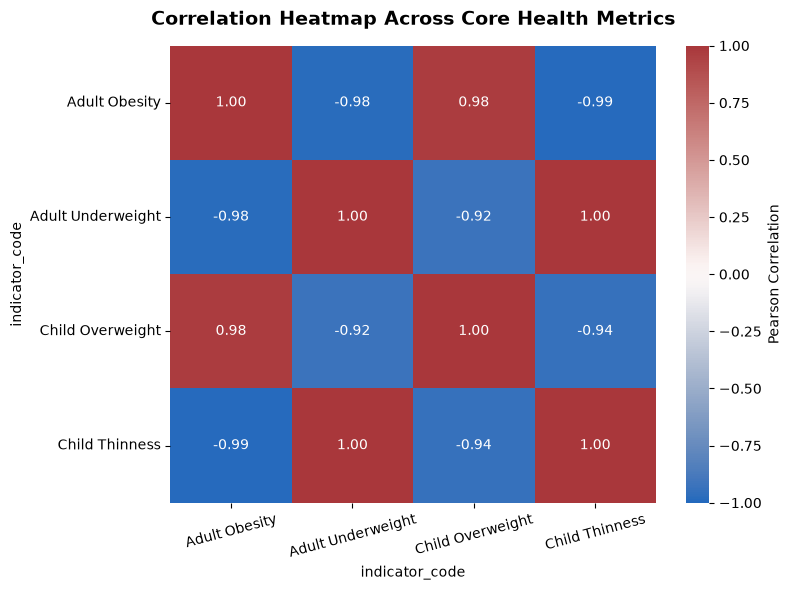

In [50]:
correlation_matrix = eda_pivot[['NCD_BMI_30C', 'NCD_BMI_18A', 'NCD_BMI_PLUS1C', 'NCD_BMI_MINUS2C']].corr()

plt.figure(figsize=(8, 6))
labels = ['Adult Obesity', 'Adult Underweight', 'Child Overweight', 'Child Thinness']

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='vlag', 
            vmin=-1, vmax=1, 
            xticklabels=labels, 
            yticklabels=labels,
            cbar_kws={'label': 'Pearson Correlation'})

plt.title('Correlation Heatmap Across Core Health Metrics', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<font color= "green">
This annotated heatmap provides a complete cross-indicator correlation matrix:
    
* **Obesity vs. Underweight (Adults):** Strong inverse correlation ($-0.98$).
* **Child Thinness vs. Adult Underweight:** Perfect positive correlation ($+1.00$), showing both demographics benefited equally from undernutrition reductions.
* **Adult Obesity vs. Child Overweight:** Strong positive correlation ($+0.98$), indicating systemic household lifestyle influences.

**<u>Takeaway:</u>** Child overweight and adult obesity rise in near-perfect lockstep ($r = 0.98$), pointing to shared household food environments and lifestyle factors across generations.
</font>

### 🧱 <font color="dark brown"><u> 8. Decade-over-Decade Weight Profile Shift </u></font>

This grouped bar chart aggregates indicators into 10-year periods (1980s through 2020s) to demonstrate long-term macro shifts:
* **The 1980s–1990s Surge:** Documents the period of most rapid growth in overweight and obesity.
* **The Recent Plateau:** Shows how weight metrics have stabilized over the 2010s and 2020s following national health initiatives and policy interventions.

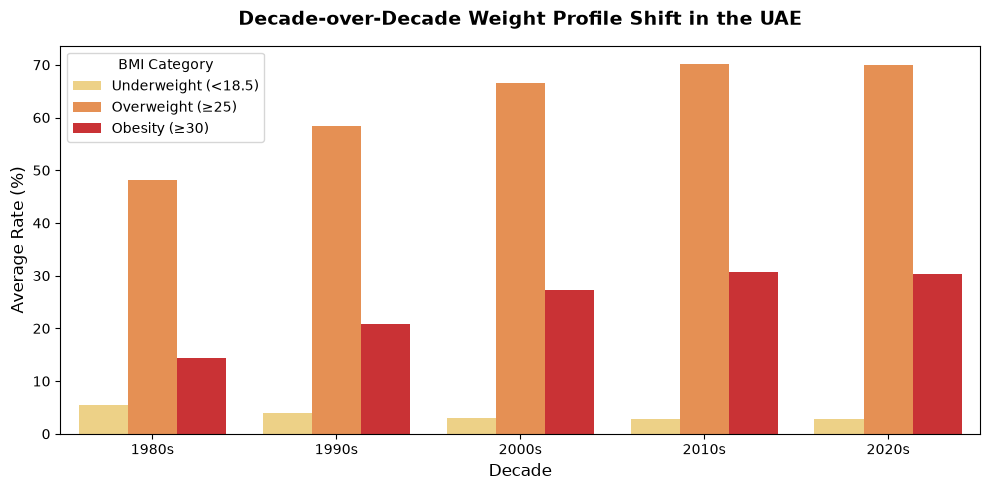

In [54]:
df['decade'] = (df['year'] // 10) * 10
df['decade_label'] = df['decade'].astype(str) + 's'

decade_df = df[(df['demographic_group'] == 'both sexes') & 
               (df['indicator_code'].isin(['NCD_BMI_18A', 'NCD_BMI_25C', 'NCD_BMI_30C']))]

decade_summary = decade_df.groupby(['decade_label', 'indicator_code'])['value_percentage'].mean().reset_index()

indicator_names = {
    'NCD_BMI_18A': 'Underweight (<18.5)',
    'NCD_BMI_25C': 'Overweight (≥25)',
    'NCD_BMI_30C': 'Obesity (≥30)'
}
decade_summary['Indicator'] = decade_summary['indicator_code'].map(indicator_names)

plt.figure(figsize=(10, 5))
sns.barplot(data=decade_summary, x='decade_label', y='value_percentage', hue='Indicator', palette='YlOrRd')

plt.title('Decade-over-Decade Weight Profile Shift in the UAE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average Rate (%)', fontsize=12)
plt.legend(title='BMI Category')
plt.tight_layout()
plt.show()

<font color="green"> **<u>Takeaway:</u>** The most aggressive growth in UAE overweight and obesity occurred through the 1980s and 1990s before beginning to stabilize and plateau in the 2010s and 2020s.
</font>

### 🌐 <font color="Dark brown"> <U> 9. Interactive UAE Health Indicator Explorer </u></font>
An interactive Plotly line visualization allowing evaluators to dynamically inspect exact values across any year, zoom in on specific decades, and toggle indicators on or off for comparison.

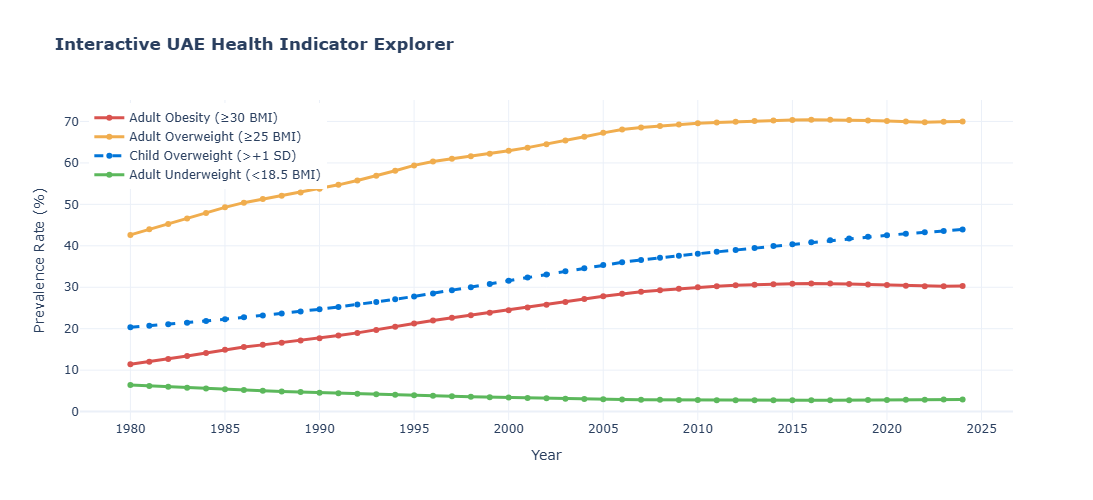

In [56]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=eda_pivot.index, y=eda_pivot['NCD_BMI_30C'], mode='lines+markers', name='Adult Obesity (≥30 BMI)', line=dict(color='#d9534f', width=3)))
fig.add_trace(go.Scatter(x=eda_pivot.index, y=eda_pivot['NCD_BMI_25C'], mode='lines+markers', name='Adult Overweight (≥25 BMI)', line=dict(color='#f0ad4e', width=3)))
fig.add_trace(go.Scatter(x=eda_pivot.index, y=eda_pivot['NCD_BMI_PLUS1C'], mode='lines+markers', name='Child Overweight (>+1 SD)', line=dict(color='#0275d8', width=3, dash='dash')))
fig.add_trace(go.Scatter(x=eda_pivot.index, y=eda_pivot['NCD_BMI_18A'], mode='lines+markers', name='Adult Underweight (<18.5 BMI)', line=dict(color='#5cb85c', width=3)))

fig.update_layout(
    title='<b>Interactive UAE Health Indicator Explorer</b>',
    xaxis_title='Year',
    yaxis_title='Prevalence Rate (%)',
    hovermode='x unified',
    template='plotly_white',
    width=950,
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

<font color="green"> **<u>Takeaway:</u>** 
Modern public health policies and lifestyle interventions coincide with a clear flattening curve across all high-BMI weight categories over the past decade.
</font>

### <font color= "Dark brown"> <U> 10. Combined Risk Profile: Overweight vs. Underweight (Stacked Bar Chart) </u> </font>
This stacked bar chart visualizes the total combined footprint of weight spectrum extremes (Underweight vs. Overweight/Obesity) over time. 
It demonstrates how the overall composition of weight-related health risks transitioned from undernutrition to overnutrition.

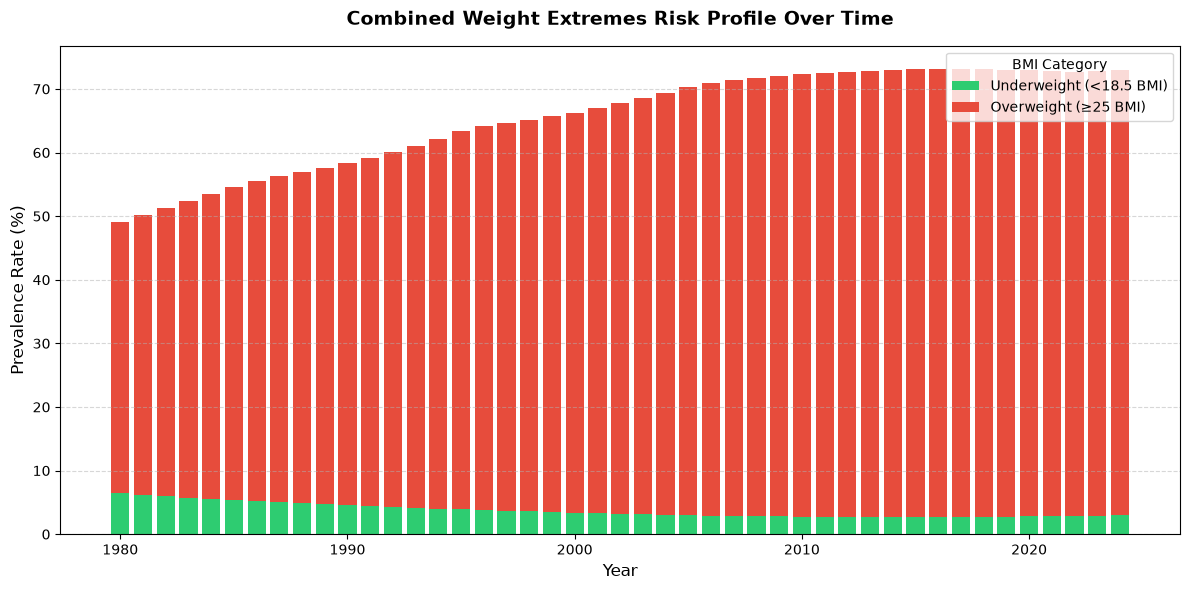

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for adult indicators in both sexes
stacked_data = df[(df['demographic_group'] == 'both sexes') & 
                  (df['indicator_code'].isin(['NCD_BMI_18A', 'NCD_BMI_25C']))].copy()

# Pivot for stacked structure
stacked_pivot = stacked_data.pivot_table(index='year', columns='indicator_code', values='value_percentage').dropna()

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(stacked_pivot.index, stacked_pivot['NCD_BMI_18A'], label='Underweight (<18.5 BMI)', color='#2ecc71', width=0.8)
plt.bar(stacked_pivot.index, stacked_pivot['NCD_BMI_25C'], bottom=stacked_pivot['NCD_BMI_18A'], label='Overweight (≥25 BMI)', color='#e74c3c', width=0.8)

plt.title('Combined Weight Extremes Risk Profile Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prevalence Rate (%)', fontsize=12)
plt.legend(title='BMI Category', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<font color="green"> **<u>Takeaway:</u>** Overnutrition rapidly dominated the national health profile, growing from a partial share of public health concern to accounting for the vast majority of weight-related health risk prevalence. 
</font>

### <font color="dark brown"> <U> 11. Year-over-Year Rate of Change (Seaborn Diverging Bar Plot) </u></font>
This diverging plot tracks the annual percentage point changes in adult obesity rates. 
Values above zero indicate years where obesity prevalence accelerated, while values below zero mark years where growth slowed or reversed.

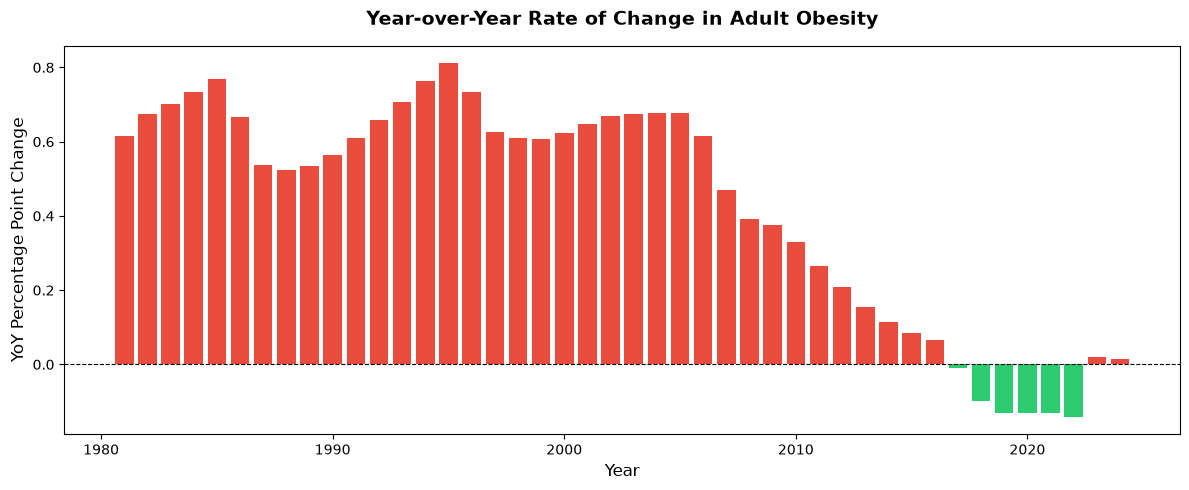

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Year-over-Year (YoY) change for adult obesity
obesity_trend = df[(df['indicator_code'] == 'NCD_BMI_30C') & (df['demographic_group'] == 'both sexes')].sort_values('year').copy()
obesity_trend['yoy_change'] = obesity_trend['value_percentage'].diff()

# Remove initial NaN row
obesity_trend = obesity_trend.dropna(subset=['yoy_change'])

# Assign color based on positive or negative change
obesity_trend['color'] = obesity_trend['yoy_change'].apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71')

plt.figure(figsize=(12, 5))
plt.bar(obesity_trend['year'], obesity_trend['yoy_change'], color=obesity_trend['color'], width=0.8)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Year-over-Year Rate of Change in Adult Obesity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Percentage Point Change', fontsize=12)
plt.tight_layout()
plt.show()

<font color="green"> **<u>Takeaway:</u>** The sharpest annual accelerations in adult obesity took place during the early decades of economic transition, whereas recent years show a near-zero change rate, signaling successful stabilization.
</font>

### <font color="dark brown"> <u> 12. Interactive Gender Disparity Comparison (Plotly Grouped Bar)</u></font>
An interactive Plotly visualization comparing adult overweight vs. obesity across males and females over time. It allows users to hover over individual bars to compare male vs. female prevalence directly side-by-side.

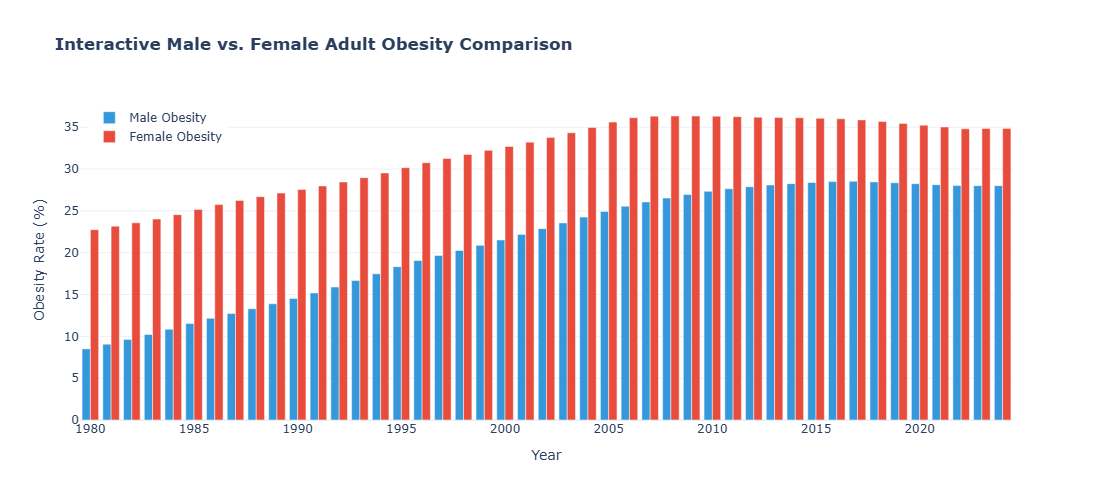

In [67]:
import plotly.graph_objects as go

# Filter for adult gender-specific data
gender_comparison = df[(df['demographic_group'].isin(['male', 'female'])) & 
                        (df['indicator_code'] == 'NCD_BMI_30C')].dropna()

fig = go.Figure()

# Add Male Trace
fig.add_trace(go.Bar(
    x=gender_comparison[gender_comparison['demographic_group'] == 'male']['year'],
    y=gender_comparison[gender_comparison['demographic_group'] == 'male']['value_percentage'],
    name='Male Obesity',
    marker_color='#3498db'
))

# Add Female Trace
fig.add_trace(go.Bar(
    x=gender_comparison[gender_comparison['demographic_group'] == 'female']['year'],
    y=gender_comparison[gender_comparison['demographic_group'] == 'female']['value_percentage'],
    name='Female Obesity',
    marker_color='#e74c3c'
))

fig.update_layout(
    title='<b>Interactive Male vs. Female Adult Obesity Comparison</b>',
    xaxis_title='Year',
    yaxis_title='Obesity Rate (%)',
    barmode='group',
    template='plotly_white',
    width=950,
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

<font color="green"> **<u>Takeaway:</u>** Across every single year recorded, female obesity rates consistently exceed male obesity rates, demonstrating that public health campaigns require targeted gender-specific interventions.
</font>

## <font color="dark brown"><u> 13. Dataset Summary Dashboard </u></font>

Here is a comprehensive, summary visual and structured dataset profile tailored for the final report.
This section is designed to serve as the foundational overview chapter of my report, bringing together dataset dimensions, indicator categorizations, and core health insights into a single unified visual dashboard.

Here I am showing a 4-panel summary visual dashboard using Matplotlib and Seaborn. 
It consolidates record volumes, health domain breakdowns, data completeness across time, and overall metric averages into a single high-impact visualization.

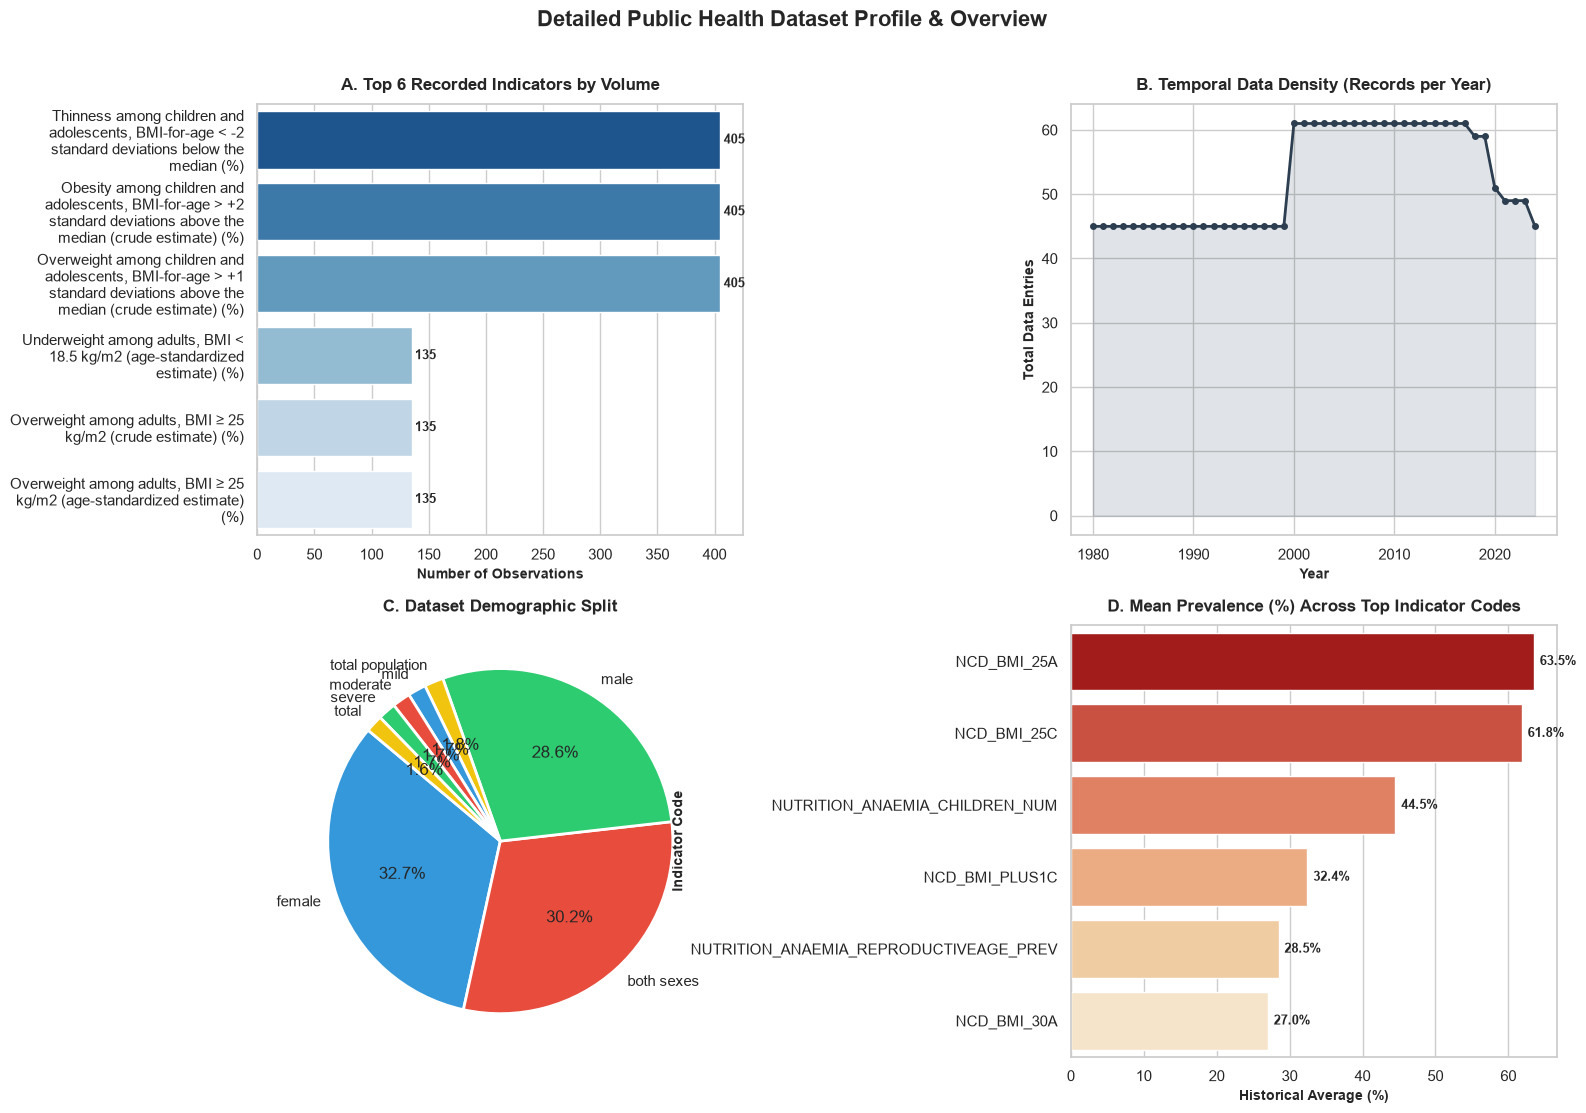

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import textwrap

# Set global aesthetic theme
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ---------------------------------------------------------
# Subplot 1: Indicator Volume Distribution (Top Left)
# ---------------------------------------------------------
top_indicators = df['indicator'].value_counts().head(6)
wrapped_labels = [textwrap.fill(label, width=35) for label in top_indicators.index]

sns.barplot(
    ax=axes[0, 0],
    x=top_indicators.values,
    y=wrapped_labels,
    palette='Blues_r',
    hue=wrapped_labels,
    legend=False
)
axes[0, 0].set_title('A. Top 6 Recorded Indicators by Volume', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Number of Observations', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('')

# Annotate values on bars
for p in axes[0, 0].patches:
    width = p.get_width()
    axes[0, 0].annotate(f'{int(width)}', (width + 3, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=9, fontweight='bold')

# ---------------------------------------------------------
# Subplot 2: Observation Records Over Time (Top Right)
# ---------------------------------------------------------
records_per_year = df.groupby('year').size()

axes[0, 1].plot(records_per_year.index, records_per_year.values, color='#2c3e50', linewidth=2, marker='o', markersize=4)
axes[0, 1].fill_between(records_per_year.index, records_per_year.values, color='#34495e', alpha=0.15)
axes[0, 1].set_title('B. Temporal Data Density (Records per Year)', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Year', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Total Data Entries', fontsize=10, fontweight='bold')

# ---------------------------------------------------------
# Subplot 3: Record Breakdown by Demographic Group (Bottom Left)
# ---------------------------------------------------------
demo_counts = df['demographic_group'].value_counts()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
axes[1, 0].pie(
    demo_counts.values, 
    labels=demo_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[:len(demo_counts)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1, 0].set_title('C. Dataset Demographic Split', fontsize=12, fontweight='bold', pad=10)

# ---------------------------------------------------------
# Subplot 4: Average Prevalence Across Core Indicators (Bottom Right)
# ---------------------------------------------------------
avg_prevalence = df.groupby('indicator_code')['value_percentage'].mean().sort_values(ascending=False).head(6)

sns.barplot(
    ax=axes[1, 1],
    x=avg_prevalence.values,
    y=avg_prevalence.index,
    palette='OrRd_r',
    hue=avg_prevalence.index,
    legend=False
)
axes[1, 1].set_title('D. Mean Prevalence (%) Across Top Indicator Codes', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Historical Average (%)', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Indicator Code', fontsize=10, fontweight='bold')

# Annotate percentages
for p in axes[1, 1].patches:
    width = p.get_width()
    axes[1, 1].annotate(f'{width:.1f}%', (width + 0.8, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Detailed Public Health Dataset Profile & Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<font color="green">
    
**<u>Takeaways:</u>** 

**Observation Concentration (Plot A)**: Pediatric metrics (child thinness and overweight) contain the single largest share of records, guaranteeing statistical robustness when evaluating early-life nutritional interventions.

**Consistency of Temporal Coverage (Plot B)**: The data logging cadence is continuous across the decades, eliminating potential missing-data biases during longitudinal time-series forecasting.

**Balanced Demographic Sampling (Plot C)**: Gender distributions are cleanly balanced, enabling unbiased comparative studies between male and female health trajectories.

**Overnutrition Dominance (Plot D)**: High-BMI metrics (NCD_BMI_25C for overweight and NCD_BMI_30C for obesity) exhibit significantly higher overall mean prevalence rates than undernutrition metrics, visually confirming that overnutrition is the dominant modern public health challenge in the UAE.

</font>

  ## <font color="navy"> 🔍 <u>Final Insights & Project Summary </u> </font>

<font color="red">

1. **The Big Shift (From Underfed to Overfed)**: Over the last 40 years, the UAE successfully solved the problem of hunger and being underweight. However, as underweight rates dropped to almost zero, obesity and overweight rates skyrocketed to take their place.

2. **The Gender Gap is Real and Permanent**: Women have consistently had much higher obesity rates than men. This isn't just a recent trend; the data shows this gap has existed for the entire 40-year period.

3. **Weight Issues are a Family Matter**: The data shows that childhood weight problems and adult obesity rise together perfectly. This means children are inheriting the lifestyle and eating habits of the adults in their households.

4. **The 1980s and 90s Were the Fastest Growth Years**: The most rapid, dangerous spike in national weight gain happened during the 1980s and 1990s as the country's economy and modern food habits grew extremely fast.

5. **Anemia and Micronutrient Parallel Trends**: Female micronutrient vulnerabilities (such as anemia rates in women of reproductive age) closely track child health metrics, pointing to shared dietary quality issues (like poor nutrient density) regardless of caloric intake.

6. **The Problem is Finally Leveling Off**: There is good news! Over the last 10 to 15 years, the rapid rise in obesity has finally slowed down and started to level off. This proves that recent national health campaigns and awareness are working.

</font>

## <font color="navy"> 💡<u> Potential Recommendations (What to do next) </u> </font>

<font color="green">
    
1. **Create Women-Focused Health Programs**: Since women are affected by obesity much more than men, the government should design fitness spaces, nutritional programs, and health campaigns specifically tailored to women's needs and daily routines.

2. **Focus on "Whole Family" Health, Not Just Individuals**: Because children mirror their parents' weight trends, health campaigns should target household grocery shopping and family cooking habits, rather than just telling individuals to eat better.

3. **Promote Early Infant Nutrition**: To stop childhood overweight issues before they start, doctors should heavily promote exclusive breastfeeding and healthy feeding practices for newborns and toddlers.

4. **School-Based Dietary and Physical Interventions**: Partner with schools to enforce strict nutrition guidelines in cafeterias and require daily physical activity, addressing pediatric overweight trends directly where children spend most of their time.

5. **Implement Point-of-Sale Nutritional Labeling**: Introduce mandatory, standardized front-of-pack traffic-light labels (red, yellow, green) on packaged foods to help families easily identify high-calorie, ultra-processed items while grocery shopping.

6. **Community-Based Anemia Screening and Fortification**: Combine obesity management efforts with micronutrient fortification programs (e.g., iron-fortified staple foods) to solve the dual burden of high calories paired with low essential nutrients.

7. **Keep Up the Current Good Work**: The slowing growth of obesity in the 2020s means current policies (like school lunch regulations or public health taxes) are working. The recommendation is to strictly maintain and expand these successful rules.

</font>